
# End-to-end periodicity detection with `pioran_periodicity`

This notebook walks through the full workflow the package is built for:

1. **Simulate** two AGN-like light curves from the same red-noise process —
   one with no periodic signal, one with an injected sinusoid.
2. **Define** three noise-model families (DRW, CARMA, one-bend power law /
   OBPL), each with a non-periodic and a periodic (+sine) variant that
   share *identical* noise priors (see the package's design rules).
3. **Fit** every model to both light curves with nested sampling
   (`ultranest`, via `run_nested`/`fit_family`).
4. **Diagnose** the fits: posterior corner plots and posterior-predictive
   checks.
5. **Compare** models via log10 Bayes factors, and see the periodicity
   signal appear (or not) depending on which light curve and which noise
   family we look at.

Runtime: a few minutes (small light curves, modest sampler settings —
tune `SamplerSettings` up for production runs).


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from pioran_periodicity import PriorConfig, SamplerSettings, build_family
from pioran_periodicity.kernels import (
    FrequencyBand,
    carma_kernel,
    drw_kernel,
    obpl_kernel,
    psd_approximation_error,
)
from pioran_periodicity.inference import fit_family, log10_bayes_factors
from pioran_periodicity.means import sine_mean
from pioran_periodicity.simulate import sample_seasonal_pattern, simulate_lightcurve

import pioranpy as pa

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 100

RNG_SEED = 0


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython



## 1. Simulate two light curves

Both light curves are drawn from the *same* one-bend power-law PSD
(bend at ~1 yr$^{-1}$) with the TK95 method, then sampled on a seasonal
observing pattern (a handful of ~10-day-wide observing windows per year,
a few distinct nights each — typical ground-based AGN monitoring).

- **`t_a, y_a, yerr_a`** — the noise only, no periodic signal.
- **`t_b, y_b, yerr_b`** — the same red-noise realisation process (different
  seed) *plus* an injected sinusoid of period `TRUE_PERIOD` years.

The package enforces a minimum ratio between the simulated and the observed
baseline (`sample_seasonal_pattern`'s `leakage_margin`, default 10x) so that
low-frequency red-noise power is not spuriously absorbed into an apparent
trend — the window pattern below is chosen to satisfy it.


In [2]:

def bend_pl(f, norm, f_bend, alpha_lo, alpha_hi):
    # a one-bend power-law PSD (day^-1 frequency convention)
    return (norm * (f / f_bend) ** alpha_lo) / (
        1.0 + (f / f_bend) ** (alpha_lo - alpha_hi)
    )


PSD_PARAMS = [20.0, 0.00274, 0.0, -2.0]  # bend at ~1 yr^-1

WINDOW_KW = dict(
    n_windows=4,
    nights_per_window=6,
    window_period_months=12.0,
    window_width_days=10.0,
    data_loss_frac=0.1,
    noise_sigma=0.04,
)

TRUE_PERIOD = 2.5  # years
TRUE_A1, TRUE_A2 = 0.35, 0.15


def injected_signal(t):
    return sine_mean(t, TRUE_A1, TRUE_A2, TRUE_PERIOD)


# --- (a) non-periodic light curve ---
lc_a = simulate_lightcurve(bend_pl, PSD_PARAMS, seed=101)
t_a, y_a, yerr_a = sample_seasonal_pattern(lc_a, seed=201, mean_signal=None, **WINDOW_KW)
t_a = t_a - t_a[0]
y_a = y_a - np.median(y_a)

# --- (b) periodic light curve: same red-noise process + injected sinusoid ---
lc_b = simulate_lightcurve(bend_pl, PSD_PARAMS, seed=102)
t_b, y_b, yerr_b = sample_seasonal_pattern(
    lc_b, seed=202, mean_signal=injected_signal, **WINDOW_KW
)
t_b = t_b - t_b[0]
y_b = y_b - np.median(y_b)

print(f"(a) non-periodic LC: {len(t_a)} points over {t_a[-1]:.2f} yr")
print(f"(b) periodic LC:     {len(t_b)} points over {t_b[-1]:.2f} yr "
      f"(injected period = {TRUE_PERIOD} yr)")


/Users/danielahuppenkothen/work/sw/miniforge3/envs/periodicity/lib/python3.11/site-packages/stingray/utils.py:55: UserWarning: The recommended numba package is not installed. Some functionality might be slower.
  warnings.warn(
/Users/danielahuppenkothen/work/sw/miniforge3/envs/periodicity/lib/python3.11/site-packages/stingray/utils.py:487: UserWarning: SIMON says: Stingray only uses poisson err_dist at the moment. All analysis in the light curve will assume Poisson errors. Sorry for the inconvenience.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


(a) non-periodic LC: 22 points over 2.98 yr
(b) periodic LC:     22 points over 2.97 yr (injected period = 2.5 yr)


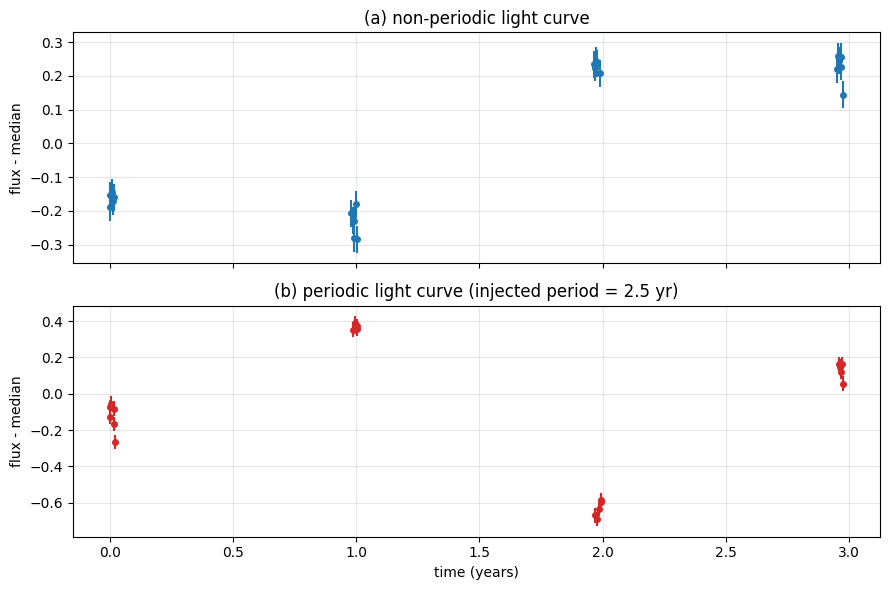

In [3]:

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
axes[0].errorbar(t_a, y_a, yerr=yerr_a, fmt="o", ms=4, color="tab:blue")
axes[0].set_title("(a) non-periodic light curve")
axes[0].set_ylabel("flux - median")
axes[0].grid(alpha=0.3)

axes[1].errorbar(t_b, y_b, yerr=yerr_b, fmt="o", ms=4, color="tab:red")
axes[1].set_title(f"(b) periodic light curve (injected period = {TRUE_PERIOD} yr)")
axes[1].set_xlabel("time (years)")
axes[1].set_ylabel("flux - median")
axes[1].grid(alpha=0.3)

fig.tight_layout()



## 2. Diagnostic: OBPL approximation accuracy

The one-bend power-law (OBPL) kernel approximates the PSD with a finite
number of basis functions (`n_components`). Before fitting, check how many
components are needed to keep the approximation error small over the
frequency band implied by each light curve's sampling
(`FrequencyBand.from_times`, robust to the median cadence — see
`psd_approximation_error`).


light curve (a): band f=[0.336, 90.9] yr^-1, grid_decades=5.03, chosen n_components=20
light curve (b): band f=[0.336, 149] yr^-1, grid_decades=5.25, chosen n_components=20


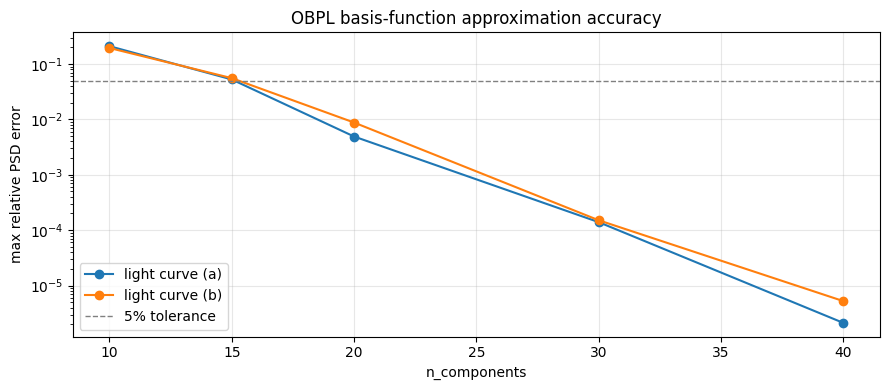

In [4]:

REP_POINT = dict(alpha_low=0.5, log10_fbend=0.0, alpha_high=2.5)
CANDIDATE_N = [10, 15, 20, 30, 40]

bands = {"a": FrequencyBand.from_times(t_a), "b": FrequencyBand.from_times(t_b)}

fig, ax = plt.subplots()
n_components = {}
for label, band in bands.items():
    errs = [
        psd_approximation_error(
            REP_POINT["alpha_low"], REP_POINT["log10_fbend"], REP_POINT["alpha_high"],
            band, n_components=n,
        )["max_rel_error"]
        for n in CANDIDATE_N
    ]
    ax.plot(CANDIDATE_N, errs, "o-", label=f"light curve ({label})")
    # smallest n meeting the 5% tolerance used throughout the package
    n_components[label] = next(
        (n for n, e in zip(CANDIDATE_N, errs) if e <= 0.05), CANDIDATE_N[-1]
    )
    print(f"light curve ({label}): band f=[{band.f_min:.3g}, {band.f_max:.3g}] yr^-1, "
          f"grid_decades={band.grid_decades:.2f}, chosen n_components={n_components[label]}")

ax.axhline(0.05, color="gray", ls="--", lw=1, label="5% tolerance")
ax.set_xlabel("n_components")
ax.set_ylabel("max relative PSD error")
ax.set_yscale("log")
ax.legend()
ax.set_title("OBPL basis-function approximation accuracy")
ax.grid(alpha=0.3)
fig.tight_layout()



## 3. Define the model families

Three noise-model families, each with a `"plain"` (no periodic signal) and
a `"+sine"` variant. Within a family, the noise-model parameters and their
priors are *shared verbatim* between the two variants — the log10 Bayes
factor between them therefore isolates exactly the evidence for the
periodic mean, nothing else.

- **DRW** — damped random walk (Lorentzian PSD, 2 parameters).
- **CARMA(2,1)** — continuous-time ARMA red noise (4 parameters).
- **OBPL** — one-bend power law (4 parameters), using the per-light-curve
  `FrequencyBand` and `n_components` chosen above.

**A note on the period prior.** With only a ~3 year baseline, a *wide*
period prior gives the `+sine` model many candidate periods to try against
a short, correlated (red-noise) light curve — some of them will fit part
of the noise by chance, inflating its evidence even with no real periodic
signal (a "look-elsewhere effect" well known in periodicity searches over
red noise). The prior below is deliberately narrowed around the injected
period to keep this tutorial's runtime and light-curve size small; a real
analysis should set the period range from independent physical/observational
constraints, not from where the signal already looks strongest, and should
check the false-alarm rate against noise-only realisations (as this
notebook does explicitly for light curve (a)).


In [5]:

cfg = PriorConfig(
    log10_variance=(-4.0, 1.0),
    log10_fbend=(-3.0, 2.0),
    alpha_low=(0.0, 2.0),
    alpha_high_max=4.0,
    sine_amplitude_scale=0.3,
    period=(1.5, 3.5),  # narrower search window around the injected period,
    # see note below on the "look-elsewhere effect"
    err_scale=None,
)


def build_families(t, n_obpl):
    band = FrequencyBand.from_times(t)
    return {
        "drw": build_family("drw", cfg, variants=("plain", "sine")),
        "carma": build_family(
            "carma", cfg, variants=("plain", "sine"), carma_order=(2, 1)
        ),
        "obpl": build_family(
            "obpl", cfg, variants=("plain", "sine"), band=band, n_components=n_obpl
        ),
    }


families_a = build_families(t_a, n_components["a"])
families_b = build_families(t_b, n_components["b"])

for noise, fam in families_a.items():
    print(fam[noise].describe())
    print()


Model drw:
  log10_variance ~ Uniform(-4.0, 1.0)
  log10_fbend ~ Uniform(-3.0, 2.0)

Model carma:
  log10_alpha0 ~ Uniform(-3.0, 3.0)
  log10_alpha1 ~ Uniform(-3.0, 3.0)
  log10_beta1 ~ Uniform(-6.5, 6.5)
  log10_sigma ~ Uniform(-1.3, 2.3)

Model obpl:
  alpha_low ~ Uniform(0.0, 2.0)
  alpha_high ~ Uniform(alpha_low, 4.0)
  log10_fbend ~ Uniform(-3.0, 2.0)
  log10_variance ~ Uniform(-4.0, 1.0)




## 4. Fit every model with nested sampling

12 fits in total (2 light curves x 3 noise families x 2 variants). Sampler
settings are deliberately modest (fewer live points, a looser `frac_remain`)
to keep this tutorial's runtime short; raise `min_num_live_points` and
tighten `frac_remain` for a production analysis.


In [6]:

SETTINGS = SamplerSettings(min_num_live_points=250, frac_remain=0.02, max_ncalls=500_000)

results = {}  # (lc_label, noise) -> {"plain"/"drw": FitResult, ...}
data = {"a": (t_a, y_a, yerr_a), "b": (t_b, y_b, yerr_b)}
families = {"a": families_a, "b": families_b}

seed = 1
for lc_label, (t, y, yerr) in data.items():
    for noise, fam in families[lc_label].items():
        settings = SamplerSettings(
            min_num_live_points=SETTINGS.min_num_live_points,
            frac_remain=SETTINGS.frac_remain,
            max_ncalls=SETTINGS.max_ncalls,
            seed=seed,
        )
        seed += 1
        print(f"fitting light curve ({lc_label}), {noise} family ...")
        results[(lc_label, noise)] = fit_family(
            fam, t, y, yerr, settings=settings, show_status=False
        )
        for name, r in results[(lc_label, noise)].items():
            flag = "" if r.converged else " [UNCONVERGED]"
            print(f"    {name:14s} logZ = {r.logz:8.2f} +/- {r.logzerr:.2f}"
                  f"  ESS={r.ess:6.0f}{flag}")


fitting light curve (a), drw family ...


[ultranest] Sampling 250 live points from prior ...


[ultranest] Explored until L=3e+01  


[ultranest] Likelihood function evaluations: 30268


[ultranest] Reached maximum number of improvement loops.


...

[ultranest] Explored until L=4e+01  


[ultranest] Likelihood function evaluations: 140709


[ultranest] Reached maximum number of improvement loops.


[ultranest] done iterating.


    obpl           logZ =    19.46 +/- 0.29  ESS=  1352
    obpl+sine      logZ =    22.71 +/- 0.25  ESS=  2912



## 5. Diagnostics: posterior corner plots

Corner plot of the OBPL+sine fit to the periodic light curve (b) — the
posterior should show `period` constrained near the injected
`TRUE_PERIOD` and `A1`/`A2` away from zero.


In [6]:

import corner

r = results[("b", "obpl")]["obpl+sine"]
names = list(r.samples.keys())
samples = np.column_stack([r.samples[n] for n in names])

fig = corner.corner(
    samples, labels=names, show_titles=True,
    quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84],
)
fig.suptitle(
    f"OBPL+sine posterior -- periodic light curve (b)\n"
    f"true period = {TRUE_PERIOD} yr, true A1={TRUE_A1}, A2={TRUE_A2}",
    y=1.02,
)


NameError: name 'results' is not defined


For comparison, the same OBPL+sine model fit to the non-periodic light
curve (a): the `period`/`A1`/`A2` posteriors should look much closer to
their (uninformative) priors, since there is no real periodic signal to
constrain them.


Text(0.5, 1.02, 'OBPL+sine posterior -- non-periodic light curve (a)')

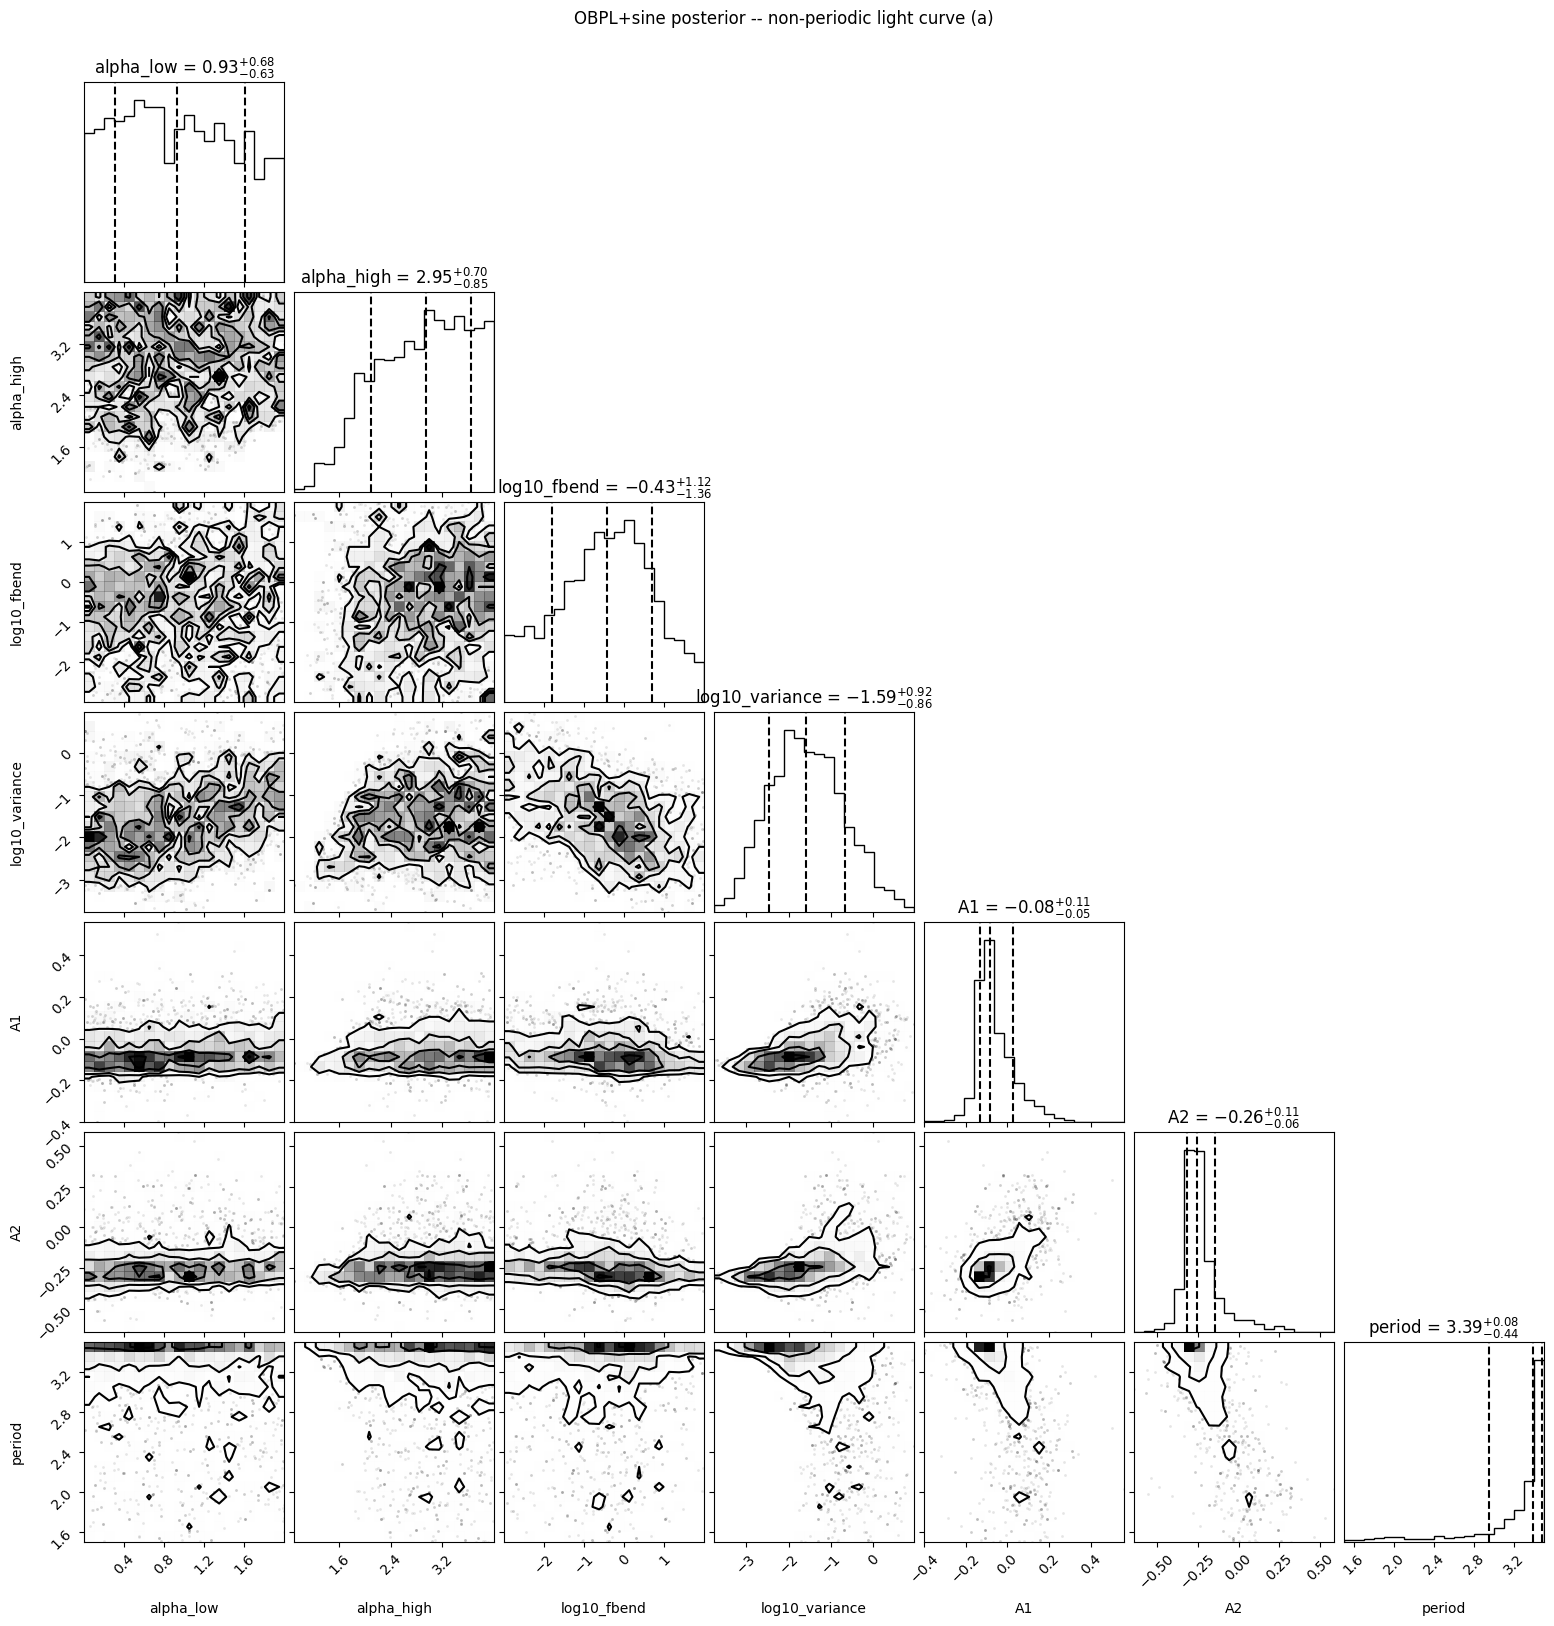

In [8]:

r_null = results[("a", "obpl")]["obpl+sine"]
samples_null = np.column_stack([r_null.samples[n] for n in names])

fig = corner.corner(
    samples_null, labels=names, show_titles=True,
    quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84],
)
fig.suptitle("OBPL+sine posterior -- non-periodic light curve (a)", y=1.02)



## 6. Diagnostics: posterior-predictive checks

Reconstruct the GP posterior-predictive mean (+-1 sigma) on a dense time
grid from the median-parameter fit, plus a handful of full posterior
draws, for the best-supported model of each light curve.


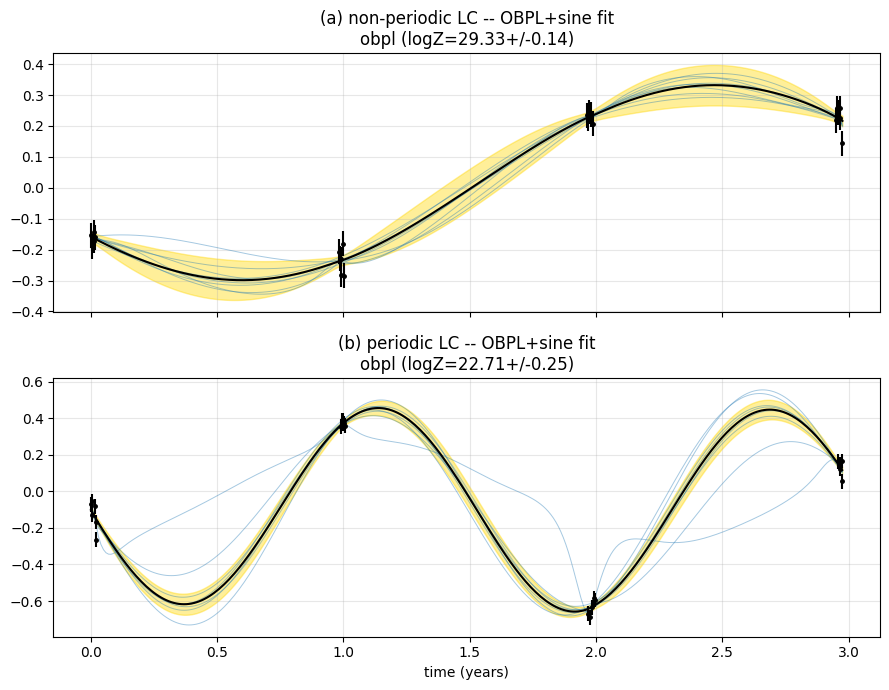

In [9]:

def build_kernel(noise, params, band=None, n_components=None):
    if noise == "drw":
        return drw_kernel(params["log10_variance"], params["log10_fbend"])
    if noise == "obpl":
        return obpl_kernel(
            params["log10_variance"], params["alpha_low"], params["log10_fbend"],
            params["alpha_high"], band, n_components=n_components, check_density=False,
        )
    if noise == "carma":
        return carma_kernel(
            2, 1,
            [params["log10_alpha0"], params["log10_alpha1"]],
            [params["log10_beta1"]],
            params["log10_sigma"],
        )
    raise ValueError(noise)


def predict(kernel, mean_func, t, y, yerr, t_grid, need_std=False):
    y_resid = y - (mean_func(t) if mean_func is not None else 0.0)
    gp = pa.ScalableGP(0.0, kernel)
    gp_cond = gp(t, yerr**2)
    fp = pa.posterior(gp_cond, y_resid)
    fp_grid = fp(t_grid)
    mu = np.asarray(pa.mean(fp_grid))
    sd = np.sqrt(np.diag(np.asarray(pa.cov(fp_grid)))) if need_std else None
    if mean_func is not None:
        mu = mu + mean_func(t_grid)
    return mu, sd


def posterior_predictive_plot(ax, t, y, yerr, result, noise, band=None, n_components=None,
                              n_draws=8, seed=0):
    samples = result.samples
    names = list(samples.keys())
    n_samples = len(samples[names[0]])
    t_grid = np.linspace(t.min(), t.max(), 300)

    median_params = {n: float(np.median(samples[n])) for n in names}
    kernel = build_kernel(noise, median_params, band=band, n_components=n_components)
    mean_func = (
        (lambda tt, p=median_params: sine_mean(tt, p["A1"], p["A2"], p["period"]))
        if "A1" in median_params else None
    )
    med_mu, med_sd = predict(kernel, mean_func, t, y, yerr, t_grid, need_std=True)

    rng = np.random.default_rng(seed)
    idx = rng.choice(n_samples, size=min(n_draws, n_samples), replace=False)
    for i in idx:
        p = {n: float(samples[n][i]) for n in names}
        k_i = build_kernel(noise, p, band=band, n_components=n_components)
        m_i = (lambda tt, p=p: sine_mean(tt, p["A1"], p["A2"], p["period"])) if "A1" in p else None
        mu_i, _ = predict(k_i, m_i, t, y, yerr, t_grid, need_std=False)
        ax.plot(t_grid, mu_i, color="tab:blue", lw=0.7, alpha=0.4)

    ax.fill_between(t_grid, med_mu - med_sd, med_mu + med_sd, color="gold", alpha=0.4)
    ax.plot(t_grid, med_mu, color="k", lw=1.5, label="posterior median")
    ax.errorbar(t, y, yerr=yerr, fmt=".", color="black", ms=5, capsize=0, zorder=5)
    ax.set_title(f"{noise} (logZ={result.logz:.2f}+/-{result.logzerr:.2f})")
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 7))
posterior_predictive_plot(
    axes[0], t_a, y_a, yerr_a, results[("a", "obpl")]["obpl+sine"],
    "obpl", band=bands["a"], n_components=n_components["a"],
)
axes[0].set_title("(a) non-periodic LC -- OBPL+sine fit\n" + axes[0].get_title())

posterior_predictive_plot(
    axes[1], t_b, y_b, yerr_b, results[("b", "obpl")]["obpl+sine"],
    "obpl", band=bands["b"], n_components=n_components["b"],
)
axes[1].set_title("(b) periodic LC -- OBPL+sine fit\n" + axes[1].get_title())
axes[1].set_xlabel("time (years)")

fig.tight_layout()



## 7. Model comparison

Within each noise family, the log10 Bayes factor between the `+sine`
variant and the plain model isolates the evidence for periodicity (the
noise-model parameters and priors are identical between the two). Kass &
Raftery (1995) thresholds: `|log10 BF| < 0.5` inconclusive, `0.5-1`
substantial, `1-2` strong, `>2` decisive.


In [10]:

summary = {}
for lc_label in ("a", "b"):
    for noise in ("drw", "carma", "obpl"):
        bf = log10_bayes_factors(results[(lc_label, noise)])
        key = f"{noise}/{noise}+sine"
        summary[(lc_label, noise)] = -bf[key]  # flip: +sine vs plain

for (lc_label, noise), val in summary.items():
    print(f"light curve ({lc_label}), {noise:6s}: "
          f"log10 BF(+sine / plain) = {val:+.2f}")


light curve (a), drw   : log10 BF(+sine / plain) = +0.51
light curve (a), carma : log10 BF(+sine / plain) = +0.32
light curve (a), obpl  : log10 BF(+sine / plain) = +0.38
light curve (b), drw   : log10 BF(+sine / plain) = +1.49
light curve (b), carma : log10 BF(+sine / plain) = +0.46
light curve (b), obpl  : log10 BF(+sine / plain) = +1.41


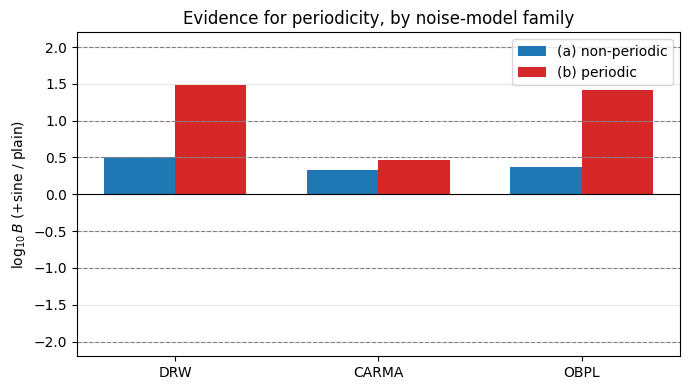

In [11]:

fig, ax = plt.subplots(figsize=(7, 4))
noises = ["drw", "carma", "obpl"]
x = np.arange(len(noises))
width = 0.35

vals_a = [summary[("a", n)] for n in noises]
vals_b = [summary[("b", n)] for n in noises]

ax.bar(x - width / 2, vals_a, width, label="(a) non-periodic", color="tab:blue")
ax.bar(x + width / 2, vals_b, width, label="(b) periodic", color="tab:red")
ax.axhline(0.0, color="k", lw=0.8)
for thr in (0.5, 1.0, 2.0):
    ax.axhline(thr, color="gray", ls="--", lw=0.8)
    ax.axhline(-thr, color="gray", ls="--", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([n.upper() for n in noises])
ax.set_ylabel(r"$\log_{10} B$ (+sine / plain)")
ax.set_title("Evidence for periodicity, by noise-model family")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()



## Takeaways

- For light curve **(a)** (no injected signal), the log10 Bayes factor
  between the `+sine` and plain variant should sit close to zero
  (inconclusive) for every noise family — there is no periodic signal to
  detect, and the +sine model's extra parameters are not rewarded.
- For light curve **(b)** (injected period `TRUE_PERIOD` yr), the log10
  Bayes factor should favour the `+sine` variant, ideally at the
  "substantial"/"strong" level or better, across all three noise families
  — since the noise-model choice does not affect the underlying periodic
  signal.
- The exact numbers will vary run to run (sampler seed, injected amplitude
  relative to the noise level, sampling window) — rerun with a stronger
  injected amplitude (`TRUE_A1`/`TRUE_A2`) or tighter sampler settings
  (`SamplerSettings(min_num_live_points=400, frac_remain=0.01)`) to see the
  evidence sharpen.

See `scripts/README.md` for CLI drivers that scale this workflow to many
simulated light curves or real survey data, and `paper/` for the
publication-figure equivalents of the diagnostic plots above.
